In [9]:
import openmc
openmc.config['cross_sections'] = '/home/elhareefmh/MC/endfb-viii.0-hdf5/cross_sections.xml'
import onix

/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another UniverseBase instance already exists with id=0.
  warn(msg, IDWarning)


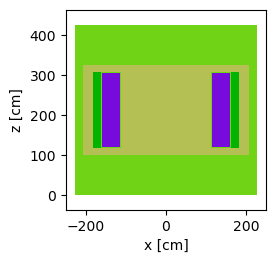

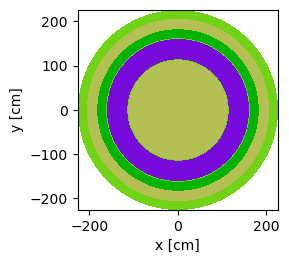

In [10]:
fuel = openmc.Material(temperature=973.15)
fuel.set_density('g/cm3', 4.1249)
fuel.add_nuclide('Li6', 1.4486e-05, 'ao')
fuel.add_nuclide('Li7', 0.28970514, 'ao')
fuel.add_nuclide('Th232', 0.07471028, 'ao')
fuel.add_nuclide('U233', 0.009401869, 'ao')
fuel.add_nuclide('F19', 0.626168224, 'ao')

fertile = openmc.Material(temperature=973.15)
fertile.set_density('g/cm3', 4.1249)
fertile.add_nuclide('Li6', 1.4486e-05, 'ao')
fertile.add_nuclide('Li7', 0.28970514, 'ao')
fertile.add_nuclide('Th232', 0.08411214953, 'ao')
fertile.add_nuclide('F19', 0.6261682243, 'ao')

b4c = openmc.Material(temperature=973.15)
b4c.set_density('g/cm3', 2.52)
b4c.add_nuclide('C12', 0.19778, 'ao')
b4c.add_nuclide('C13', 0.00222, 'ao')
b4c.add_nuclide('B10', 0.1584, 'ao')
b4c.add_nuclide('B11', 0.6416, 'ao')

reflector = openmc.Material(temperature=973.15)
reflector.set_density('g/cm3', 10)
reflector.add_element('Ni', 0.79432, 'ao')
reflector.add_element('W', 0.09976, 'ao')
reflector.add_element('Cr', 0.08014, 'ao')
reflector.add_element('Mo', 0.00736, 'ao')
reflector.add_element('Fe', 0.00632, 'ao')
reflector.add_element('Ti', 0.00295, 'ao')
reflector.add_element('C', 0.00294, 'ao')
reflector.add_element('Mn', 0.00257, 'ao')
reflector.add_element('Si', 0.00252, 'ao')
reflector.add_element('Al', 0.00052, 'ao')
reflector.add_element('B', 0.00033, 'ao')
reflector.add_element('P', 0.00023, 'ao')
reflector.add_element('S', 0.00003, 'ao')

gas = openmc.Material(temperature=973.15)
gas.set_density('g/cm3', 1.0)
gas.add_nuclide('He4', 1, 'ao')

materials = openmc.Materials([fuel, fertile, b4c, reflector, gas])
materials.cross_sections = '/home/elhareefmh/MC/endfb-viii.0-hdf5/cross_sections.xml'

s1 = openmc.ZCylinder(r=112.75)
s2 = openmc.ZCylinder(r=114.75)
s3 = openmc.ZCylinder(r=160.75)
s4 = openmc.ZCylinder(r=162.75)
s5 = openmc.ZCylinder(r=182.75)
s6 = openmc.ZCylinder(r=206.45)
s7 = openmc.ZCylinder(r=226.45)

h1 = openmc.ZPlane(z0=0.0)
h2 = openmc.ZPlane(z0=100.0)
h3 = openmc.ZPlane(z0=118.75)
h4 = openmc.ZPlane(z0=120.75)
h5 = openmc.ZPlane(z0=304.75)
h6 = openmc.ZPlane(z0=306.75)
h7 = openmc.ZPlane(z0=325.5)
h8 = openmc.ZPlane(z0=425.5)
h9 = openmc.ZPlane(z0=425.7483)

core_region = -s1 & +h2 & -h7
loop_region = -s6 & +h2 & -h7 & ~ ( -s5 & +h3 & -h6)
blanket_region = -s3 & +s2 & +h4 & -h5
struct_region = -s4 & +s1 & +h3 & -h6 & ~ blanket_region
protector_region = -s5 & +s4 & +h3 & - h6
reflector_region = -s7 & +h1 & -h8 & ~ (-s6 & +h2 & -h7)
reprocessing_region = -s7 & +h8 & -h9


s7.boundary_type = 'vacuum'
h1.boundary_type = 'vacuum'
h8.boundary_type = 'vacuum'

cell1 = openmc.Cell(name = 'core', region=core_region, fill=fuel)
cell2 = openmc.Cell(name = 'loop', region=loop_region, fill=fuel)
cell3 = openmc.Cell(name = 'blanket', region=blanket_region, fill=fertile)
cell4 = openmc.Cell(region=struct_region, fill=reflector)
cell5 = openmc.Cell(region=protector_region, fill=b4c)
cell6= openmc.Cell(region=reflector_region, fill=reflector)
cell7= openmc.Cell(name = 'reprocessing_plant',region=reprocessing_region, fill=fuel)

geo_universe = openmc.Universe()
geo_universe.add_cells([cell1, cell2, cell3, cell4, cell5, cell6, cell7])

# Create root Cell
root_cell = openmc.Cell(name='root cell')
root_cell.fill = geo_universe
root_cell.region = -s7 & +h1 & -h9

# Create root Universe
root_universe = openmc.Universe(universe_id=0, name='root universe')
root_universe.add_cell(root_cell)

root_universe.plot(width=(500, 500), pixels=40000, basis='xz', color_by='material')
root_universe.plot(color_by='material')

geometry = openmc.Geometry(root=root_universe)

In [11]:
settings = openmc.Settings()
settings.run_mode='eigenvalue'
space = openmc.stats.Point((0.0, 0.0, 212.75))
source = openmc.IndependentSource(space=space)
settings.source = source
settings.batches = 120
settings.inactive = 40
settings.particles = 1000

settings.temperature['method'] = 'interpolation'
settings.temperature['tolerance'] = 100.0
settings.temperature['multipole'] = True

settings.export_to_xml()
geometry.export_to_xml()
materials.export_to_xml()
#openmc.run()

In [12]:
import math
macrostep_vector = [1e-6, 1e-4, 1e-2, 0.5, 1, 3, 5, 10, 20, 30,40, 50, 60, 70, 80, 100, 120, 140, 170, 200] 
macrostep_unit = 'y'

norma_vector = [43.7650]*len(macrostep_vector) #kW/l
norma_unit = 'power'

periods = [macrostep_vector[i] - macrostep_vector[i-1] if i>0 else macrostep_vector[i] for i in range(len(macrostep_vector))]
microstep_vector = [math.ceil(period/3) for period in periods]

sequence1 = onix.Sequence(1)
sequence1.set_macrostep(macrostep_vector, macrostep_unit)
sequence1.set_norma(norma_vector, norma_unit)
sequence1.microstep_vector = microstep_vector

sequence1.flux_approximation ='iv'

msr = onix.couple.Couple_msr()

msr.set_bounding_box([-226.45, -226.45, 0.0], [226.45, 226.45, 425.5])

loop_dict = {
             
             
             'core': {
                      'upstream_cells': [('loop', 1)],
                      'elements_removal': [('H', 0.0231), ('He', 0.0231), ('N', 0.0231), ('O', 0.0231), 
                                            ('Ne', 0.0231), ('Ar', 0.0231), ('Kr', 0.0231), ('Nb', 0.0231), 
                                            ('Mo', 0.0231), ('Tc', 0.0231), ('Ru', 0.0231), ('Rh', 0.0231), 
                                            ('Pd', 0.0231), ('Ag', 0.0231), ('Sb', 0.0231), ('Te', 0.0231), 
                                            ('Xe', 0.0231), ('Rn', 0.0231)
                                            ] 
             },
             'loop': {
                     'upstream_cells': [('core',0.99999989711), ('reprocessing_plant',1.0289e-07)]
             },
             'reprocessing_plant': {
                     'upstream_cells': [('core',1.0289e-07)],
                     'elements_removal': [('Zn', 1.1574e-04), ('Ga', 1.1574e-04), ('Ge', 1.1574e-04), ('As', 1.1574e-04), 
                                            ('Se', 1.1574e-04), ('Br', 1.1574e-04), ('Rb', 1.1574e-04), ('Sr', 1.1574e-04), 
                                            ('Y', 1.1574e-04), ('Zr', 1.1574e-04), ('Cd', 1.1574e-04), ('In', 1.1574e-04), 
                                            ('Sn', 1.1574e-04), ('I', 1.1574e-04), ('Cs', 1.1574e-04), ('Ba', 1.1574e-04), 
                                            ('La', 1.1574e-04), ('Ce', 1.1574e-04), ('Pr', 1.1574e-04), ('Nd', 1.1574e-04), 
                                            ('Pm', 1.1574e-04), ('Sm', 1.1574e-04), ('Eu', 1.1574e-04), ('Gd', 1.1574e-04), 
                                            ('Tb', 1.1574e-04), ('Dy', 1.1574e-04), ('Ho', 1.1574e-04), ('Er', 1.1574e-04), 
                                            ('Tm', 1.1574e-04), ('Yb', 1.1574e-04)
                                            ],
             },
             
            'blanket':{
                    'elements_removal': [('H', 0.0231), ('He', 0.0231), ('N', 0.0231), ('O', 0.0231), 
                                            ('Ne', 0.0231), ('Ar', 0.0231), ('Kr', 0.0231), ('Nb', 0.0231), 
                                            ('Mo', 0.0231), ('Tc', 0.0231), ('Ru', 0.0231), ('Rh', 0.0231), 
                                            ('Pd', 0.0231), ('Ag', 0.0231), ('Sb', 0.0231), ('Te', 0.0231), 
                                            ('Xe', 0.0231), ('Rn', 0.0231),   #Nobel gases 
                
                                            ],
                
                    'recycling': ('core', [ ('Th', 3*6.3197e-10),
                                            ('U', 6.3197e-08), ('Np', 6.3197e-08), 
                                            ('Pu', 6.3197e-08), ('Am', 6.3197e-08), ('Cm', 6.3197e-08), ('Bk', 6.3197e-08), 
                                            ('Cf', 6.3197e-08), ('Es', 6.3197e-08), ('Fm', 6.3197e-08), ('Md', 6.3197e-08), 
                                            ('No', 6.3197e-08), ('Lr', 6.3197e-08)
                                            ]),
                    'external_salt_stream': (0.46296296, [('Li-6', 1.08E-06), ('Li-7', 2.15E-02), ('Th-232', 6.25E-03), ('F-19', 4.65E-02)]),
            },
            
        
}
msr.vol_flow_rate = 4.5e6

msr.select_bucells(loop_dict = loop_dict)

msr.import_openmc(root_cell)

msr.set_sequence(sequence1)

vol_dict = {'core': 9005949.76, 'loop': 8.9715e+06, 'reprocessing_plant':40E3, 'blanket':7.3257e+06, 'total volume':6.8548e+07}
msr.set_vol(vol_dict)



msr.debug_connectivity_matrix = True
msr.burn()








    .*#############*        #####,        #####    ####.   #####,       #####,
   ######* ###########*     #######.      #####    ####.    .#####    #####*
 ######## # ############    #########     #####    ####.     .#####, #####*
######## ##*.##.#########,  ##########    #####    ####.        ########
#######,,### ,.. ########   ##### ,#####  #####    ####.         *#####
####### ##### ### #######   #####   #####,#####    ####.       .########,
 ,####* *######## .#####    #####     #########    ####.     ,#####, #####.
  *#######  *  *######*     #####      *#######    ####.    ######    *#####
      *############,        #####       .######    ####.   #####.       #####*


An open-source depletion code for reactor simulation and nuclear archaeology






{}
=== OpenMC pre-run ===





/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/volume.py:107: UserWarning: Specified bounding box is smaller than computed bounding box for cell 23. Volume calculation may be incorrect!
  warnings.warn(msg)
/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/volume.py:107: UserWarning: Specified bounding box is smaller than computed bounding box for cell 24. Volume calculation may be incorrect!
  warnings.warn(msg)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")





----  Default fission yields library set for system  ----
---- /home/elhareefmh/MC/ONIX/onix/data/default_libs/fy_lib_reduced ----



----  Path for cross sections library ----


----  /home/elhareefmh/MC/endfb-viii.0-hdf5  ----






***********Sampling isomeric branching data***********






***********Sampling point-wise cross section data***********




 Time to sample cross sections: 2.384185791015625e-07

[Connectivity debug] BUCell ordering and matrix block layout
  loop_dict key order: ['core', 'loop', 'reprocessing_plant', 'blanket']
  system.get_bucell_list() order: ['core', 'loop', 'blanket', 'reprocessing_plant']
  BUCell block assignments:
    'core' -> rows/cols [0:1638], volume=9005949.76
    order OK: cell 'core' matches reference block order (1638 entries)
    'loop' -> rows/cols [1638:3276], volume=8971500.0
    order OK: cell 'loop' matches reference block order (1638 entries)
    'blanket' -> rows/cols [3276:4914], volume=7325700.0
    order OK: cell 'blanket' m

...




=== Salameche Burn 20 ===






                  .@.                                       
             *************                                  
            ****************                                
         *.*************@****                               
         @&***********  @@@***                              
       **************@@@@@@***                              
     &***************@#### ***                              
     *************************                         #    
      ************************                        ##    
  &    *(#********/&( (((*****                     ######,# 
  *#****,*@*********@/**%/****(   #***/@*          ######## 
  **********/*****&,,,,%****************(*          .#.#####
    ********&.,,,,,,,.....**************           ....#####
      &(((((...............****((((((              .......##
         *(.................*******                .......# 
           ................../*****/              

/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=555.
  warn(msg, IDWarning)
/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=558.
  warn(msg, IDWarning)
/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=561.
  warn(msg, IDWarning)
/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=564.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/home/elhareefmh/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:280: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(





 >>>>>> ONIX burn took 14669.199455738068 seconds <<<<<<< 



